In [1]:
import pickle
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
from pathlib import Path
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib as mpl

from stats_utils import kde_scatter_estimate,KDEScatterData, plot_scatter_from_kde

In [2]:
mpl.rcdefaults()
#* SMALLER SIZE
# plt.rc('font', size=12)          # controls default text sizes
# plt.rc('axes', titlesize=14)     # fontsize of the axes title
# plt.rc('axes', labelsize=12)     # fontsize of the x and y labels
# plt.rc('xtick', labelsize=12)    # fontsize of the tick labels
# plt.rc('ytick', labelsize=12)    # fontsize of the tick labels
# plt.rc('legend', fontsize=12)    # legend fontsize
# plt.rc('figure', titlesize=14)   # fontsize of the figure title

#* BIGGER SIZE
plt.rcParams.update({"text.usetex": True})
plt.rcParams["font.family"] = 'STIXGeneral'
plt.rc('font', size=22)          # controls default text sizes
plt.rc('axes', titlesize=14)     # fontsize of the axes title
plt.rc('axes', labelsize=22)     # fontsize of the x and y labels
plt.rc('xtick', labelsize=22)    # fontsize of the tick labels
plt.rc('ytick', labelsize=22)    # fontsize of the tick labels
plt.rc('legend', fontsize=22)    # legend fontsize
plt.rc('figure', titlesize=14)   # fontsize of the figure title


In [3]:
BATCH = "008"

In [4]:
# Use .expanduser() to turn "~" into "/home/yourusername"
PARQUETS = Path("~/tesi/sarafu/final_simulations").expanduser()
PICKLED = Path("~/papers/adtxns_paper/pickled_data").expanduser()
SARAFU_PICKLED = PICKLED / "sarafu"
NODES = Path("~/tesi/sarafu/final_simulations").expanduser() / BATCH

FIGURES = Path("~/papers/adtxns_paper/figures/kde").expanduser()


In [5]:
with open(SARAFU_PICKLED / "sarafu.pkl", "rb") as f:
    sarafu = pickle.load(f)

In [65]:
metadata = pickle.load(open(PICKLED / BATCH / "metadata.pkl", "rb"))
# metadata

In [66]:
burstiness = 0.25
spending_noise = 1
QUERY = f"s == {spending_noise} and burstiness == {burstiness}"

In [67]:
# for file in os.listdir(PICKLED / BATCH / "kde"):
#     # print(PICKLED / BATCH / "kde"/file)
#     if file.startswith("nodes"):
#         fname = PICKLED / BATCH / "kde"/ file
#         k1 = pickle.load(open(fname, "rb"))
#         ax, sc, cb = plot_scatter_from_kde(k1, cmap="plasma", scatter_kw={"s": 5, "alpha": 0.7},log_scale=True)



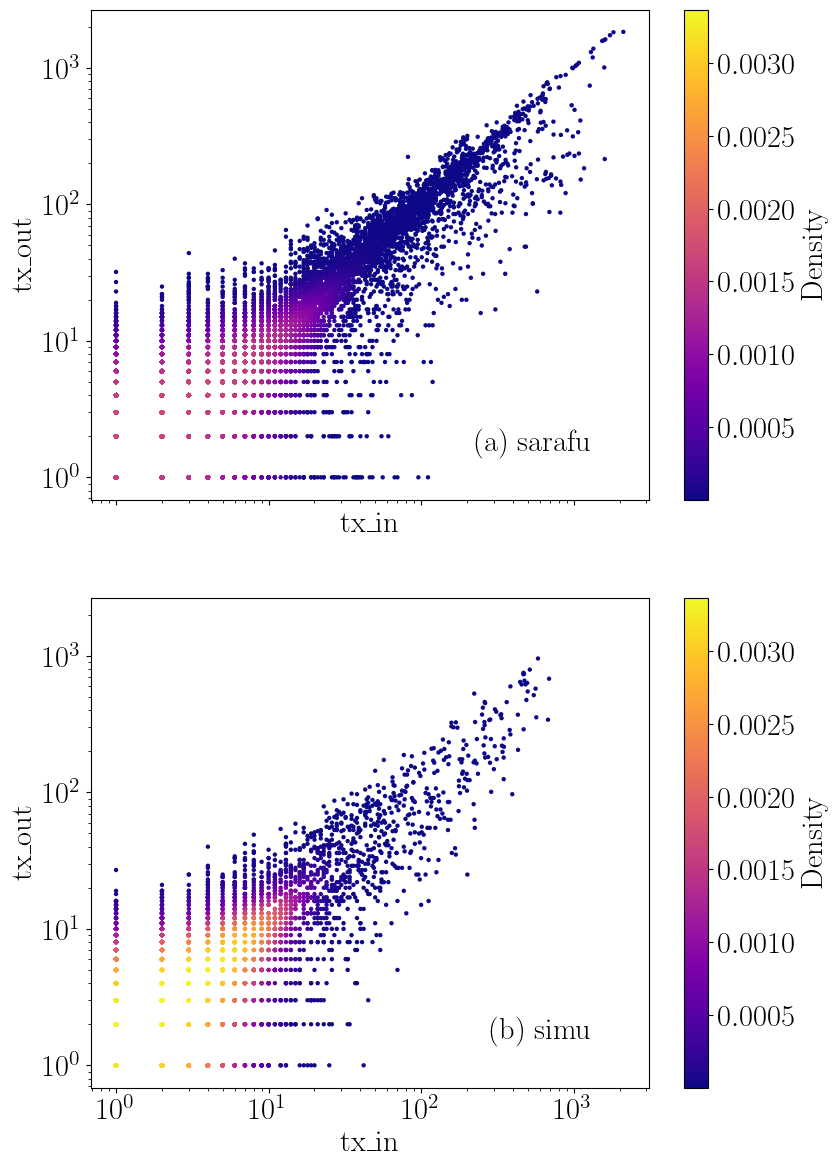

In [69]:

#* DOUBLE SCATTER WITH KDE SHARING THE COLORBAR *

keyword = "tx_in-tx_out"


simu_id = metadata.query(QUERY).iloc[0].simulation_id
# compute KDEs once
k1 = pickle.load(open(SARAFU_PICKLED / "kde" / f"sarafu__metric={keyword}__s=NA__b=NA.pkl", "rb"))
k2 = pickle.load(open(PICKLED / BATCH / "kde" / f"simulation__008__{simu_id}__metric={keyword}__s={spending_noise}__b={burstiness}.pkl", "rb"))



# shared normalization (critical)
z_all = np.hstack([k1.z, k2.z])
norm = mcolors.Normalize(vmin=z_all.min(), vmax=z_all.max())

by_rows = 0
by_cols = not by_rows

if by_rows:
    disp = 'rows'
    rows,cols = 1,2
    fig, axs = plt.subplots(rows,cols, figsize=(9*cols,7*rows), sharex=True, sharey=True)

if by_cols:
    disp = 'cols'
    rows,cols = 2,1
    fig, axs = plt.subplots(rows,cols, figsize=(9*cols,7*rows), sharex=True, sharey=True)
# plot, no colorbar on individual axes
ax1, sc1, _ = plot_scatter_from_kde(
    k1,
    ax=axs[0],
    norm=norm,
    # colorbar=False,
    log_scale=True,
    x_label="tx_in",
    y_label="tx_out",
)

ax1.text(
    0.9,
    0.1,
    f"(a) sarafu",
    transform=ax1.transAxes,
    ha="right",
)

ax2, sc2, _ = plot_scatter_from_kde(
    k2,
    ax=axs[1],
    norm=norm,
    # colorbar=False,
    log_scale=True,
    x_label="tx_in",
    y_label="tx_out",
    
)

ax2.text(
    0.9,
    0.1,
    f"(b) simu ",
    transform=ax2.transAxes,
    ha="right",
)

# single shared colorbar
# cbar = fig.colorbar(sc1, ax=axs, label="Density", shrink=0.6)



plt.show()



fig.savefig(
    FIGURES / f"{disp}__metrics={keyword}__s={spending_noise}__b={burstiness}.pdf"
)




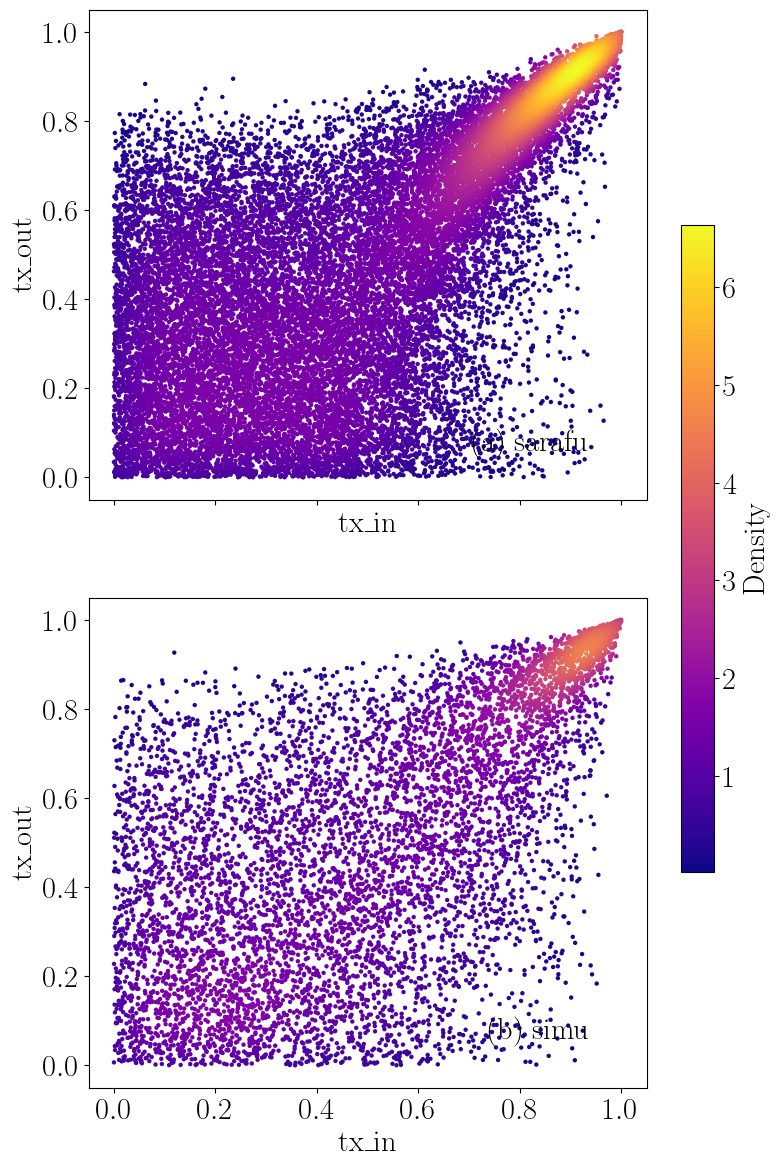

In [ ]:

#* DOUBLE SCATTER WITH KDE SHARING THE COLORBAR *

keyword = "copula-tx_in-tx_out"



simu_id = metadata.query(QUERY).iloc[0].simulation_id
# compute KDEs once
k1 = pickle.load(open(SARAFU_PICKLED / "kde" / f"sarafu__metric={keyword}__s=NA__b=NA.pkl", "rb"))
k2 = pickle.load(open(PICKLED / BATCH / "kde" / f"simulation__008__{simu_id}__metric={keyword}__s={spending_noise}__b={burstiness}.pkl", "rb"))



# shared normalization (critical)
z_all = np.hstack([k1.z, k2.z])
norm = mcolors.Normalize(vmin=z_all.min(), vmax=z_all.max())

by_rows = 0
by_cols = not by_rows

if by_rows:
    disp = 'rows'
    rows,cols = 1,2
    fig, axs = plt.subplots(rows,cols, figsize=(9*cols,7*rows), sharex=True, sharey=True)

if by_cols:
    disp = 'cols'
    rows,cols = 2,1
    fig, axs = plt.subplots(rows,cols, figsize=(9*cols,7*rows), sharex=True, sharey=True)
# plot, no colorbar on individual axes
ax1, sc1, _ = plot_scatter_from_kde(
    k1,
    ax=axs[0],
    norm=norm,
    # colorbar=False,
    # log_scale=True,
    x_label="tx_in",
    y_label="tx_out",
)

ax1.text(
    0.9,
    0.1,
    f"(a) sarafu",
    transform=ax1.transAxes,
    ha="right",
)

ax2, sc2, _ = plot_scatter_from_kde(
    k2,
    ax=axs[1],
    norm=norm,
    # colorbar=False,
    # log_scale=True,
    x_label="tx_in",
    y_label="tx_out",
    
)

ax2.text(
    0.9,
    0.1,
    f"(b) simu ",
    transform=ax2.transAxes,
    ha="right",
)

# single shared colorbar
# cbar = fig.colorbar(sc1, ax=axs, label="Density", shrink=0.6)



plt.show()



fig.savefig(
    FIGURES / f"{disp}__metrics={keyword}__s={spending_noise}__b={burstiness}.pdf"
)




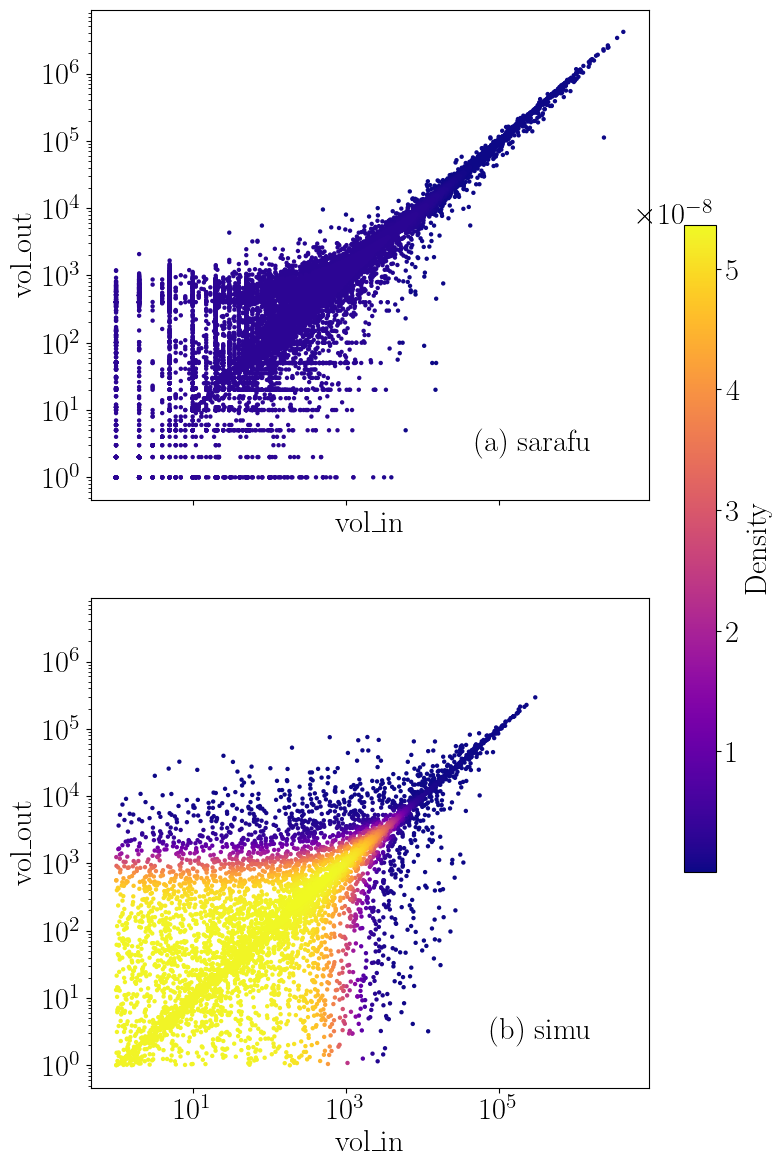

In [58]:

#* DOUBLE SCATTER WITH KDE SHARING THE COLORBAR *

keyword = "vol_in-vol_out"
x_label = "vol_in"
y_label = "vol_out"


simu_id = metadata.query(QUERY).iloc[0].simulation_id
# compute KDEs once
k1 = pickle.load(open(SARAFU_PICKLED / "kde" / f"sarafu__metric={keyword}__s=NA__b=NA.pkl", "rb"))
k2 = pickle.load(open(PICKLED / BATCH / "kde" / f"simulation__008__{simu_id}__metric={keyword}__s={spending_noise}__b={burstiness}.pkl", "rb"))



# shared normalization (critical)
z_all = np.hstack([k1.z, k2.z])
norm = mcolors.Normalize(vmin=z_all.min(), vmax=z_all.max())

by_rows = 0
by_cols = not by_rows

if by_rows:
    disp = 'rows'
    rows,cols = 1,2
    fig, axs = plt.subplots(rows,cols, figsize=(9*cols,7*rows), sharex=True, sharey=True)

if by_cols:
    disp = 'cols'
    rows,cols = 2,1
    fig, axs = plt.subplots(rows,cols, figsize=(9*cols,7*rows), sharex=True, sharey=True)
# plot, no colorbar on individual axes
ax1, sc1, _ = plot_scatter_from_kde(
    k1,
    ax=axs[0],
    norm=norm,
    colorbar=False,
    log_scale=True,
    x_label=x_label,
    y_label=y_label,
)

ax1.text(
    0.9,
    0.1,
    f"(a) sarafu",
    transform=ax1.transAxes,
    ha="right",
)

ax2, sc2, _ = plot_scatter_from_kde(
    k2,
    ax=axs[1],
    norm=norm,
    colorbar=False,
    log_scale=True,
    x_label=x_label,
    y_label=y_label,
    
)

ax2.text(
    0.9,
    0.1,
    f"(b) simu ",
    transform=ax2.transAxes,
    ha="right",
)

# single shared colorbar
cbar = fig.colorbar(sc1, ax=axs, label="Density", shrink=0.6)



plt.show()



fig.savefig(
    FIGURES / f"{disp}__metrics={keyword}__s={spending_noise}__b={burstiness}.pdf"
)




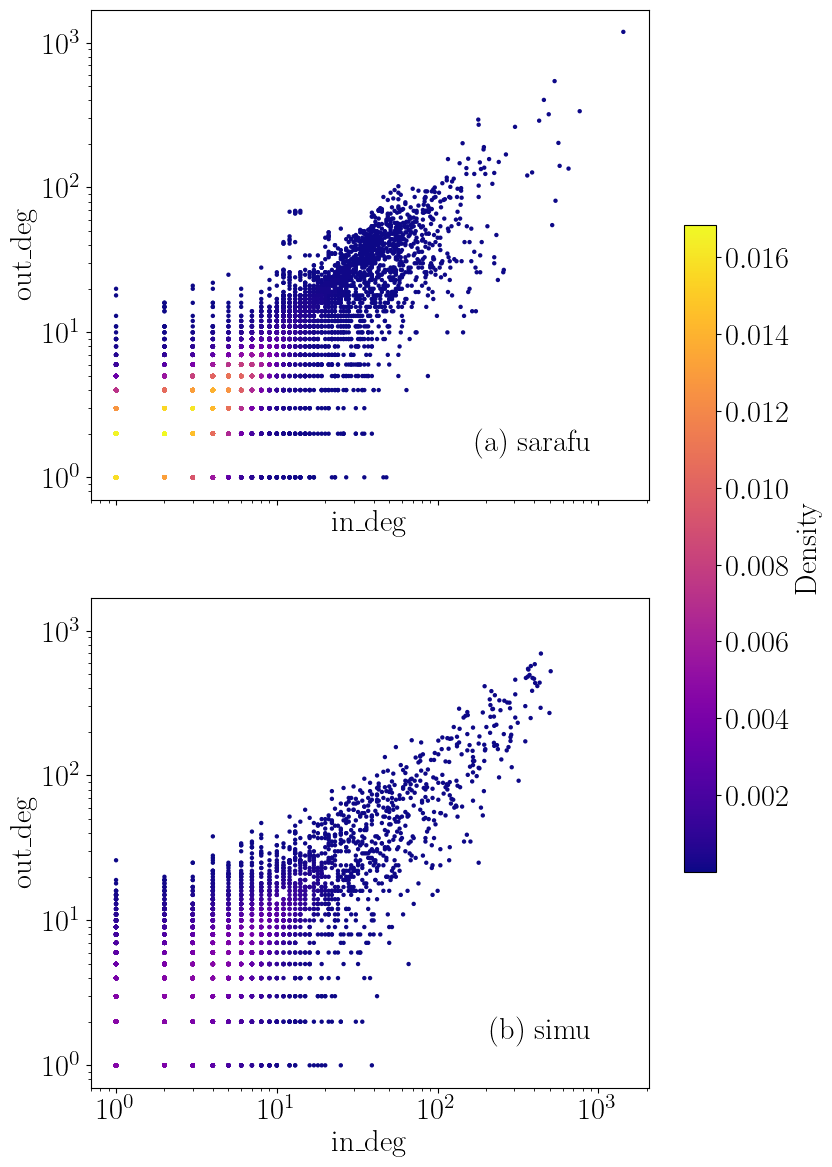

In [59]:

#* DOUBLE SCATTER WITH KDE SHARING THE COLORBAR *

keyword = "in_deg-out_deg"
x_label = "in_deg"
y_label = "out_deg"


simu_id = metadata.query(QUERY).iloc[0].simulation_id
# compute KDEs once
k1 = pickle.load(open(SARAFU_PICKLED / "kde" / f"sarafu__metric={keyword}__s=NA__b=NA.pkl", "rb"))
k2 = pickle.load(open(PICKLED / BATCH / "kde" / f"simulation__008__{simu_id}__metric={keyword}__s={spending_noise}__b={burstiness}.pkl", "rb"))



# shared normalization (critical)
z_all = np.hstack([k1.z, k2.z])
norm = mcolors.Normalize(vmin=z_all.min(), vmax=z_all.max())

by_rows = 0
by_cols = not by_rows

if by_rows:
    disp = 'rows'
    rows,cols = 1,2
    fig, axs = plt.subplots(rows,cols, figsize=(9*cols,7*rows), sharex=True, sharey=True)

if by_cols:
    disp = 'cols'
    rows,cols = 2,1
    fig, axs = plt.subplots(rows,cols, figsize=(9*cols,7*rows), sharex=True, sharey=True)
# plot, no colorbar on individual axes
ax1, sc1, _ = plot_scatter_from_kde(
    k1,
    ax=axs[0],
    norm=norm,
    colorbar=False,
    log_scale=True,
    x_label=x_label,
    y_label=y_label,
)

ax1.text(
    0.9,
    0.1,
    f"(a) sarafu",
    transform=ax1.transAxes,
    ha="right",
)

ax2, sc2, _ = plot_scatter_from_kde(
    k2,
    ax=axs[1],
    norm=norm,
    colorbar=False,
    log_scale=True,
    x_label=x_label,
    y_label=y_label,
    
)

ax2.text(
    0.9,
    0.1,
    f"(b) simu ",
    transform=ax2.transAxes,
    ha="right",
)

# single shared colorbar
cbar = fig.colorbar(sc1, ax=axs, label="Density", shrink=0.6)



plt.show()



fig.savefig(
    FIGURES / f"{disp}__metrics={keyword}__s={spending_noise}__b={burstiness}.pdf"
)




[np.float64(37554021.54917751),
 np.float64(12795691.377917288),
 np.float64(891153.638077081),
 np.float64(1950127.092449772),
 np.float64(562.190707147),
 np.float64(38340615.3853008),
 np.float64(35592971.65031481),
 np.float64(59388.119577587),
 np.float64(34110357.017435595),
 np.float64(69656457.89376275),
 np.float64(12903758.673550056),
 np.float64(0.038597703),
 np.float64(1998189.656989694),
 np.float64(7164949.971389832),
 np.float64(394664.737286508),
 np.float64(7715.713719606),
 np.float64(625429.777164162),
 np.float64(5891877.257806956),
 np.float64(38559513.85643089),
 np.float64(3909999.686684477),
 np.float64(5510496.670644163),
 np.float64(8200785.406444731),
 np.float64(18058.866283893),
 np.float64(1103.872295678),
 np.float64(43.334967613),
 np.float64(0.17712152),
 np.float64(101204.399142265),
 np.float64(41915.894559384),
 np.float64(607128.375518381),
 np.float64(762626.254788101),
 np.float64(3305703.250980556),
 np.float64(837800.830377996),
 np.float64(387